The purpose of this notebook is to take a csv file of all possible candidate control sources for each pulsar and calculate chi^2 and DoF values for every source, which will then allow me to sort by the chi^2 and DoF values to get the best possible control sources for each pulsar.

In [1]:
#imoprting required modules
import numpy as np
import pandas as pd

from astropy.coordinates import SkyCoord

from vasttools.query import Query

In [2]:
import logging
logging.basicConfig(level=201)

In [3]:
#calculates a weighted mean flux density for a single source
def weighted_mean_flux_density(source_df):
    sum_1overvariance = 0
    for i in np.arange(source_df.shape[0]):
        if (not np.isnan(source_df['flux_peak'].iloc[i])):
            oneOverVariance = 1 / source_df['rms_image'].iloc[i]
            sum_1overvariance += (oneOverVariance ** 2)
    sumSovervariance = 0
    for i in np.arange(source_df.shape[0]):
        if (not np.isnan(source_df['flux_peak'].iloc[i])):
            S = source_df['flux_peak'].iloc[i]
            var = source_df['rms_image'].iloc[i] **2
            sumSovervariance += (S/var)
    if (sum_1overvariance == 0):
        return np.nan
    return sumSovervariance / sum_1overvariance       

In [4]:
#calculates chi_squared for a single source
def chi_squared(source_df):
    n_epochs = 0
    S_weighted = weighted_mean_flux_density(source_df)
    if (S_weighted == np.nan):
        return np.nan
    temp = 0
    for i in np.arange(source_df.shape[0]):
        if (not np.isnan(source_df['flux_peak'].iloc[i])):
            S = source_df['flux_peak'].iloc[i]
            var = source_df['rms_image'].iloc[i] ** 2
            num = (S - S_weighted)**2
            temp += num / var
            n_epochs += 1
    return (temp, n_epochs)

In [5]:
# make a query, and calculate a chi squared for the source found
def query_to_chi2(measurements_row):
    my_skycoord = SkyCoord(str(measurements_row.loc['ra_deg_cont']) + " " + str(measurements_row.loc['dec_deg_cont']), unit='deg')
    my_query = Query(coords=my_skycoord, epochs='all-vast', use_tiles=True, corrected_data=False)
    my_query.find_sources()
    print("        " + "0")
    return chi_squared(my_query.results[0].measurements[my_query.results[0].measurements['freq']==887.5])

In [6]:
#datacube is cabinet, row df is a file in that cabinet, rows in the row_df are individual sources or items in the file

In [7]:
# using query_to_chi2, calculate and input a chi2 and nu_detections value into a given source dataframe
def intelligent_chi2_from_rowdf(row_df):
    counter = 0
    for i in row_df.index.values:
        print("    " + str(i))
        row_df.loc[i, ['chi_squared', 'num_detections']] =  query_to_chi2(row_df.loc[i])
        if ((row_df.loc[i, 'chi_squared'] < 30)&(row_df.loc[i, 'num_detections'] > 20)):
            counter = counter + 1
        if (counter == 3):
            return "Completed"
    return "Completed"

In [ ]:
#this will get a giant dataframe of ALL candidate control sources for ALL psrs
#I don't actually run this cell as part of this notebook, but I am including it to give an idea of how I create the list of candidate control sources
cand_controls = []
names = []
for i in np.arange(modified_results.size):
    print(i) #debugging purposes
    query_coord = SkyCoord(str(modified_results[i].measurements['ra_deg_cont'].mean()) + " " + str(modified_results[i].measurements['dec_deg_cont'].mean()), unit='deg')
    new_query = Query(coords=query_coord, epochs='23', crossmatch_radius=3600., search_around_coordinates=True, use_tiles=True, corrected_data=False)
    new_query.find_sources()
    source_flux = modified_results[i].measurements['flux_peak'].median()
    new_results = new_query.results[(new_query.results['flux_peak']>source_flux)&(new_query.results['distance']>15)]
    new_results = new_results.reset_index()
    for j in np.arange(new_results.shape[0]):
        if not (new_results.loc[j]['flux_int'] < (1.5 * new_results.loc[j]['flux_peak'])):
            new_results.drop(j, inplace=True)
    new_results1 = new_results.sort_values('distance').reset_index(drop=True)
    cand_controls.append(new_results1)
    names.append(final_df[final_df['mod_results_index']==i]['JNAME'].values[0])

cand_controls_df = pd.concat(cand_controls, keys=names) #adds a multiindex based on the corresponding pulsar name for each candidate
cand_controls_df.to_csv('cand_controls.csv')

In [8]:
#read in your csv file of potential control sources
cands_df = pd.read_csv('test_cand_controls_truncated_UPDATED_postprocessed.csv', index_col=[2,3])

In [9]:
cands_df.drop(columns=cands_df.columns[0:2], inplace=True)

In [10]:
lists=[]
for i in np.arange(cands_df.index.levels[0].values.size):
    lists.append(cands_df.loc[cands_df.index.levels[0].values[i]])

In [11]:
#creating a series where each series element is a dataframe of candidate control sources for each pulsar
#this is done to more easily iterate through each set of candidate controls
temp_series = pd.Series(lists)

In [12]:
#inserting a placeholder columns for chi2 and DoF 
for i in np.arange(temp_series.size):
    temp_series[i].insert(0, 'chi_squared', np.nan)
    temp_series[i].insert(0, 'num_detections', np.nan)

In [13]:
for i in temp_series.index.values:
    print(i)
    intelligent_chi2_from_rowdf(temp_series[i])

0
    0
        0
    249
        0
    395
        0
    458
        0
    490
        0
    767
        0
    892
        0
    893
        0
    901
        0
1
    72
        0
    111
        0
    174
        0
    270
        0
    315
        0
    403
        0
    425
        0
    566
        0
    693
        0
    751
        0
    828
        0
    842
        0
    914
        0
2
    157
        0
3
    165
        0
    203
        0
    218
        0
4
    100
        0
    193
        0
    279
        0
    548
        0
    589
        0
    685
        0
    708
        0
    790
        0
    964
        0
5
    74
        0
    91
        0
    346
        0
    380
        0
    386
        0
    502
        0
    508
        0
    513
        0
    523
        0
    579
        0
    647
        0
6
    9
        0
    54
        0
    78
        0
    95
        0
    187
        0
    307
        0
7
    81
        0
    154
        0
    206
        0
    2

In [57]:
for i in temp_series.index.values[0:19]:
    temp_series[i].to_csv('intermediates/' + str(i) + '.csv')

In [10]:
import concurrent.futures

In [14]:
#calculating values and filling the placeholder columns.
#this cell uses multiprocessing to execute faster
with concurrent.futures.ThreadPoolExecutor() as executor:
    m = executor.map(intelligent_chi2_from_rowdf, temp_series)
    list(m) #need this part to make sure the thing actually executes. Look up "lazy evaluation" for more info 

Removing source_171134.2-341626.3: Epoch 5x due to missing files
Removing source_171134.2-341626.3: Epoch 6x due to missing files
Removing source_171134.2-341626.3: Epoch 8 due to missing files
Removing source_173120.5-335325.0: Epoch 5x due to missing files
Removing source_173120.5-335325.0: Epoch 6x due to missing files
Removing source_173120.5-335325.0: Epoch 8 due to missing files
Removing source_173120.5-335325.0: Epoch 20 due to missing files
Removing source_173120.5-335325.0: Epoch 21 due to missing files
Removing source_175309.1-192103.8: Epoch 20 due to missing files
Removing source_175309.1-192103.8: Epoch 21 due to missing files
Removing source_175143.6-302246.1: Epoch 13 due to missing files
Removing source_175143.6-302246.1: Epoch 20 due to missing files
Removing source_175143.6-302246.1: Epoch 21 due to missing files
Removing source_170754.7-351036.0: Epoch 5x due to missing files
Removing source_170754.7-351036.0: Epoch 6x due to missing files
Removing source_170754.7-35

KeyboardInterrupt: 

In [18]:
#sorting by chi2
for i in np.arange(temp_series.size):
    temp_series[i].sort_values('chi_squared', inplace=True)

/tmp/ipykernel_364/2471110802.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  temp_series[i].sort_values('chi_squared', inplace=True)


In [20]:
#exporting each dataframe to a csv file named after its associated pulsar
psrs = cands_df.index.levels[0]
for i in np.arange(temp_series.size):
    temp_series[i].to_csv('controls_stats_bypsr_postprocessed/' + psrs[i] + '_controls_postprocessed.csv')

In [21]:
#creating a new iterable 'thing_list' which removes all candidate control sources that have a low number of detections
thing_list = []
for i in np.arange(temp_series.size):
    labels = temp_series[i][temp_series[i]['num_detections']<20].index.values
    thing = temp_series[i].drop(labels)
    thing_list.append(thing)
    print(thing.shape[0]) #this print statement is included to help verify that no pulsars have zero control sources with >20 detections, and will have empty dataframes as a result

8
12
1
3
8
7
4
7
8
1
2
11
7
26
8
5
8
21
3
12
9
8
11
13
16
6
2
6
4
7
13
3
7


In [22]:
#creating a ocomprehensive list of ALL the 'final candidates'
full_final_cands_list = []
psr_list = []
for i in np.arange(len(thing_list)):
    for j in thing_list[i].index.values:
        psr_list.append(i)
        full_final_cands_list.append(thing_list[i].loc[j])

In [24]:
full_final_cands_df = pd.DataFrame(full_final_cands_list)

In [25]:
#adding a placeholder column which will be filled with the pulsar partners for each control source
full_final_cands_df.insert(0, 'PSR_assoc', None)

In [26]:
full_final_cands_df.reset_index(inplace=True)

In [27]:
#filling the placeholder column
for i in full_final_cands_df.index.values:
    full_final_cands_df.loc[i, 'PSR_assoc'] = cands_df.index.levels[0].values[psr_list[i]]

In [28]:
#exporting to a csv file
full_final_cands_df.to_csv('all_final_controls.csv')

In [37]:
#creating csv of chi2 of the two lowest variability control sources for each pulsar. Useful for plotting purposes
chi_squareds = []
for i in np.arange(len(thing_list)):
    print(i)
    if (thing_list[i]['chi_squared'].size > 0):
        chi_squareds.append(thing_list[i]['chi_squared'].iloc[0])
    ##if (thing_list[i]['chi_squared'].size > 1):
    ##    chi_squareds.append(thing_list[i]['chi_squared'].iloc[1])
##pd.Series(chi_squareds).to_csv('test_control_chi_squareds.csv')

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32


In [ ]:
#reading this csv to a variable
chi_squareds = pd.read_csv('control_chi_squareds.csv')

In [ ]:
chi_squareds = list(chi_squareds['0'])

In [39]:
for i in chi_squareds:
    if i > 200:
        chi_squareds.remove(i)

In [41]:
psrs

Index(['J1708-3506', 'J1720-2933', 'J1721-3532', 'J1722-3207', 'J1727-2951',
       'J1738-3211', 'J1739-2903', 'J1740-3015', 'J1743-3150', 'J1745-3040',
       'J1749-3002', 'J1750-3157', 'J1751-2737', 'J1753-1914', 'J1756-2251',
       'J1759-2205', 'J1759-2922', 'J1759-3107', 'J1801-2304', 'J1801-2920',
       'J1801-3210', 'J1802-2124', 'J1804-2717', 'J1804-2858', 'J1807-2715',
       'J1808-2057', 'J1809-1917', 'J1809-1943', 'J1809-2109', 'J1810-2005',
       'J1811-2405', 'J1813-2621', 'J1816-2650'],
      dtype='object', name='psr_name')

In [32]:
import matplotlib.pyplot as plt
%matplotlib inline

Text(0.5, 1.0, 'Updated Control Chi^2 Histogram')

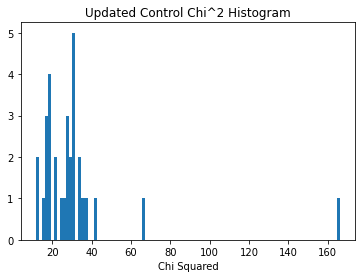

In [40]:
plt.hist(chi_squareds, bins=100)
plt.xlabel('Chi Squared')
plt.title('Updated Control Chi^2 Histogram')

In [42]:
#creating a list of the 'final candidates': the two least variable control sources for each pulsar
final_cands_list = []
psr_list = []
for i in np.arange(len(thing_list)):
    if (thing_list[i]['chi_squared'].size > 0):
        psr_list.append(i)
        final_cands_list.append(thing_list[i].iloc[0])
    if (thing_list[i]['chi_squared'].size > 1):
        psr_list.append(i)
        final_cands_list.append(thing_list[i].iloc[1])

In [43]:
final_cands_df = pd.DataFrame(final_cands_list)

In [44]:
#adding a placeholder column which will be filled with the pulsar partners for each control source
final_cands_df.insert(0, 'PSR_assoc', None)

In [45]:
final_cands_df.reset_index(inplace=True)

In [46]:
#filling the placeholder column
for i in final_cands_df.index.values:
    final_cands_df.loc[i, 'PSR_assoc'] = cands_df.index.levels[0].values[psr_list[i]]

In [47]:
#exporting to a csv file
final_cands_df.to_csv('final_controls_postprocessed.csv')

In [22]:
final_cands_df.loc[10]

level_0                           129
PSR_assoc                  J1722-3207
num_detections                   38.0
chi_squared                101.014222
index                               1
                             ...     
spectral_index_from_TT              1
flag_c4                             0
comment                           NaN
detection                        True
distance                  2328.055292
Name: 10, Length: 61, dtype: object

In [24]:
final_cands_df[final_cands_df['PSR_assoc']=='J1722-3207']

,level_0,PSR_assoc,num_detections,chi_squared,index,name,ra,dec,skycoord,stokes,...,spectral_index_err,spectral_curvature_err,rms_image,has_siblings,fit_is_estimate,spectral_index_from_TT,flag_c4,comment,detection,distance
10,129,J1722-3207,38.0,101.014222,1,source_172202.9-320745.0,260.512248,-32.129174,"<SkyCoord (ICRS): (ra, dec) in deg(260.5122478...",I,...,0.0,0.0,0.284,0,0,1,0,NaN,True,2328.055292
11,137,J1722-3207,38.0,478.294584,1,source_172202.9-320745.0,260.512248,-32.129174,"<SkyCoord (ICRS): (ra, dec) in deg(260.5122478...",I,...,0.0,0.0,0.291,1,0,1,0,NaN,True,2847.376335


In [25]:
query_coord = SkyCoord(str(final_cands_df[final_cands_df['PSR_assoc']=='J1722-3207'].loc[10]['ra_deg_cont']) + " " + str(final_cands_df[final_cands_df['PSR_assoc']=='J1722-3207'].loc[10]['dec_deg_cont']), unit='deg')
query = Query(coords=query_coord, epochs='all-vast', use_tiles=True, corrected_data=False, post_processed_data=False)
query.find_sources()

Removing source_172312.1-313150.1: Epoch 5x due to missing files
Removing source_172312.1-313150.1: Epoch 6x due to missing files
Removing source_172312.1-313150.1: Epoch 8 due to missing files
Removing source_172312.1-313150.1: Epoch 20 due to missing files
Removing source_172312.1-313150.1: Epoch 21 due to missing files


In [41]:
stuff = query.results[0].measurements[['freq', 'flux_peak', 'rms_image']]

In [42]:
stuff

,freq,flux_peak,rms_image
0,887.5,15.703000,0.260
1,887.5,15.090000,0.258
2,887.5,15.359000,0.253
3,887.5,14.943000,0.249
4,887.5,15.006000,0.279
5,887.5,15.074000,0.246
6,1367.5,9.236000,0.239
7,887.5,15.267000,0.235
8,887.5,15.320000,0.236
9,887.5,16.802999,0.284


In [43]:
stuff.drop(index=[6,9], inplace=True)

/tmp/ipykernel_540/3346623780.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  stuff.drop(index=[6,9], inplace=True)


In [44]:
chi_squared(stuff)

(70.71687666515797, 37)

In [27]:
chi_squared(query.results[0].measurements[query.results[0].measurements['freq']==887.5])

(101.01422183457618, 38)

In [31]:
%matplotlib inline

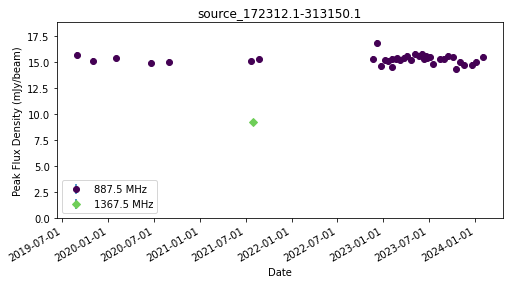

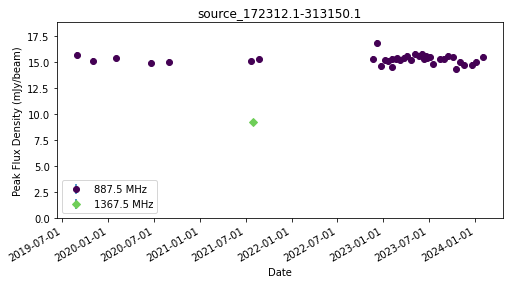

In [32]:
query.results[0].plot_lightcurve()